# Small-Scale Experiments

### Imports


In [1]:
import cupy
import matplotlib.pyplot as plt
import numpy as np
import s3fs
import zarr

from cupyx.scipy.ndimage import (
    gaussian_laplace as cupy_gaussian_laplace,
    maximum_filter as cupy_maximum_filter,
)
from deep_neurographs.utils import img_util, swc_util
from scipy.ndimage import gaussian_laplace, gaussian_filter, maximum_filter, center_of_mass
from skimage.measure import label
from skimage.feature import peak_local_max
from time import time

%matplotlib inline

IMG_PREFIX = {
    "685221": "exaSPIM_685221_2024-04-12_11-46-38_fusion_2024-07-22_21-00-15",
    "703070": "exaSPIM_703070_2024-07-09_12-52-33_flatfield-correction_2024-07-18_12-43-27_fusion_2024-08-02_17-11-59",
    "706301": "exaSPIM_706301_2024-04-23_11-24-24_fusion_2024-05-21_00-00-03",
    "708369": "exaSPIM_708369_2024-04-08_15-20-36_fusion_2024-05-20_23-30-43",
    "709393": "exaSPIM_709393_2024-04-17_09-37-51_fusion_2024-07-27_00-20-20",
    "715345": "exaSPIM_715345_2024-06-07_10-03-37_fusion_2024-07-02_10-30-40"
}

In [2]:
# Subroutines
def rescale(arr, clip_bool=True):
    if clip_bool:
        arr = np.clip(arr, 0, np.percentile(arr, 99.99))
    arr -= np.min(arr)
    arr = (2**16 - 1) * (arr / np.max(arr))
    return (arr).astype(np.uint16)


def get_mip(arr, axis=0, clip_bool=False):
    mip = np.max(arr, axis=axis)
    mip = rescale(mip, clip_bool=clip_bool)
    return mip


def read_from_s3(img, voxel, shape, from_center=True):
    start, end = img_util.get_start_end(voxel, shape, from_center=from_center)
    return img[0, 0, start[2]:end[2], start[1]:end[1], start[0]:end[0]]


def plot_mips(volume, prefix="", clip_bool=True):
    fig, axs = plt.subplots(1, 3, figsize=(10, 4))
    axs_names = ["XY", "XZ", "YZ"]
    for i in range(3):
        axs[i].imshow(get_mip(volume, axis=i, clip_bool=clip_bool))
        axs[i].set_title(prefix + axs_names[i], fontsize=16)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
    plt.tight_layout()
    plt.show()


### Opem img

In [99]:
# Parameters
s3_bucket = "aind-open-data"
dataset = "706301"
downsample_factor = 3

# Initializations
fs = s3fs.S3FileSystem()
s3_url = f"s3://{s3_bucket}/{IMG_PREFIX[dataset]}/fused.zarr/{downsample_factor}/"

# Open img
store = s3fs.S3Map(root=s3_url, s3=fs)
img = zarr.open(store, mode='r')
print("img.shape:", img.shape)

img.shape: (1, 1, 3625, 3642, 7791)


### Read img

In [4]:
traceable_somas = [
    [18403.324, 11245.411, 2675.9985],
    [23425.596, 8926.942, 2185.401],
    [18400.334,11231.872,2683.3584],
    [21624.133,7740.173,12768.359],
    [22883.316,4323.8574,16284.648],
    [43937.27,5479.154,12344.152],
]

bright_nonsomas = [
    [20026.29,6470.747,14384.427],
    [18330.354,3822.579,14477.964],
    [22800.148,2251.1611,16850.379],
    [37846.895,6913.5713,20431.992],
    [43469.51,4820.5303,16769.32],
    [44225.082,4402.9487,15589.198],
    [22086.203,16967.01,14625.586],
    [20239.145,21295.611,11517.228],
]

In [125]:
voxel 

array([2208, 1329, 1667])

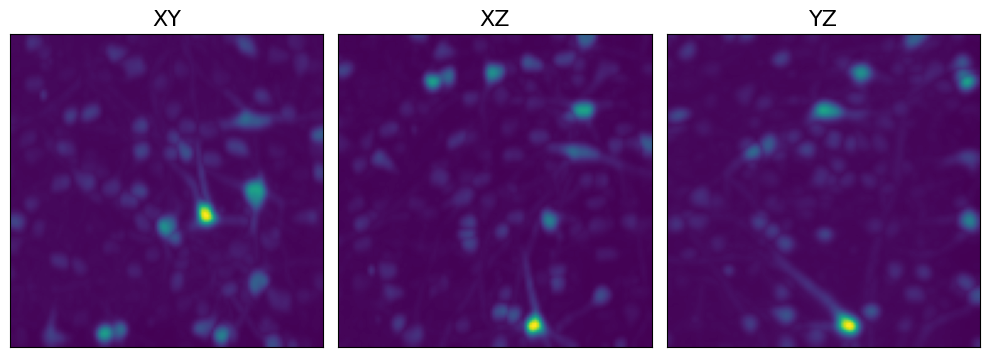

/tmp/ipykernel_138/310731900.py:6: RuntimeWarning: invalid value encountered in divide
  arr = (2**16 - 1) * (arr / np.max(arr))
/tmp/ipykernel_138/310731900.py:7: RuntimeWarning: invalid value encountered in cast
  return (arr).astype(np.uint16)


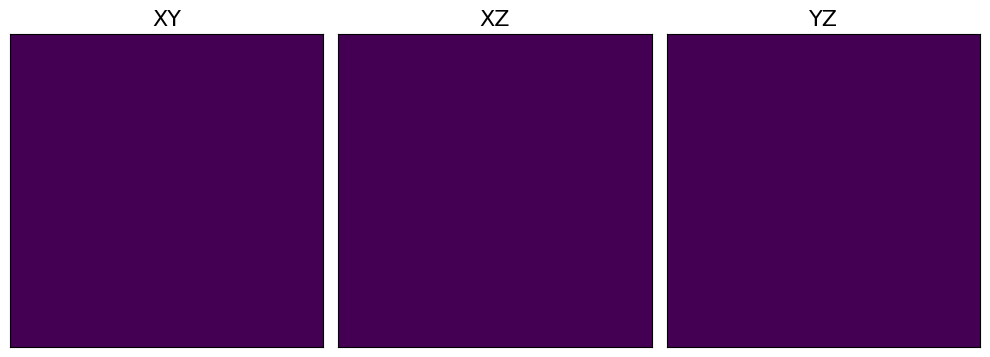

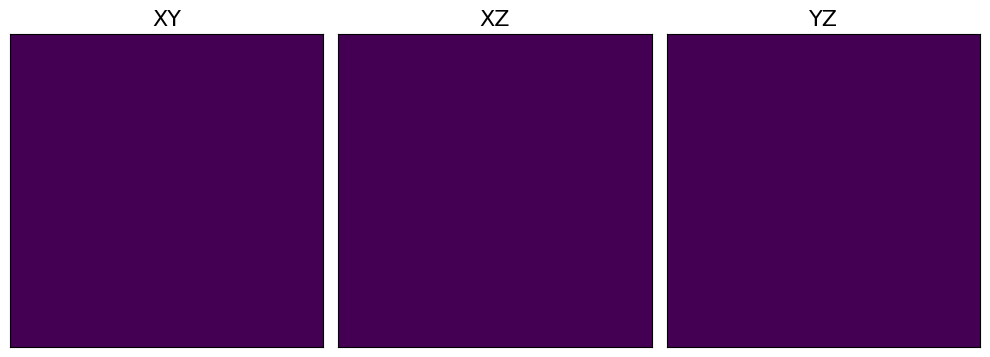

# Objects Detected: 0
[]


In [132]:
# Region of interest
idx = 4
shape = [128, 128, 128]
from_center = True

# Read img
voxel = img_util.to_voxels([13212.672, 7952.736, 13336.0], downsample_factor=downsample_factor)
img_chunk = read_from_s3(img, voxel, shape, from_center=from_center)

# Smooth with Gaussian Filter
img_chunk = gaussian_filter(img_chunk, [1.5, 1.5, 1])
plot_mips(img_chunk)

# Compute LoG
t0 = time()
log_img = gaussian_laplace(img_chunk, 10)
plot_mips(log_img)

# Find blob centroids
labels, n_labels = label(log_img > 1000, return_num=True)
plot_mips(labels)

print("# Objects Detected:", n_labels)
print(center_of_mass(img_chunk, labels=labels, index=np.arange(1, n_labels)))


## Large-Scale Experiment

In [29]:
from tqdm import tqdm

import random


In [134]:
def sliding_window_coords_3d(image, window_size, overlap):
    # Calculate the stride based on the overlap and window size
    stride = tuple(w - o for w, o in zip(window_size, overlap))
    
    # Get dimensions of the image and window
    _, _, x_dim, y_dim, z_dim  = image.shape
    x_win, y_win, z_win  = window_size
    x_stride, y_stride, z_stride  = stride

    # Loop over the image with the sliding window
    coordinates = []
    for x in range(0, x_dim - x_win + 1, x_stride):
        for y in range(0, y_dim - y_win + 1, y_stride):
            for z in range(0, z_dim - z_win + 1, z_stride):
                coordinates.append((x + x_win // 2, y + y_win // 2, z + z_win // 2))
    return coordinates


def find_candidates(img_patch):
    # Run image filters
    img_patch = gaussian_filter(img_patch, [1.5, 1.5, 1.0])
    log_img_patch = gaussian_laplace(img_patch, 10)

    # Find blobs
    labels, k = label(log_img_patch > 1000, return_num=True)
    if k > 1:
        index = np.arange(1, k)
        centers = center_of_mass(img_patch, labels=labels, index=index)
    else:
        centers = list()
    return centers, log_img_patch


### Soma Candidate Detection

In [24]:
t0 = time()
find_candidates(img_chunk)
print("Runtime:", time() - t0)

Runtime: 0.8601865768432617


In [ ]:
# Parameters
window_size = (128, 128, 128)
overlap = (32, 32, 32)

# Initializations
coords = sliding_window_coords_3d(img, window_size, overlap)
output_dir = "/root/capsule/results"

# Detection
candidates = list()
for coord in tqdm(random.sample(coords, 2000)):
    #coord = [2208, 1329, 1667]
    img_patch = read_from_s3(img, coord, window_size, from_center=True)
    candidates_i, log_img_patch = find_candidates(img_patch)
    if len(candidates_i) > 0:
        for center in candidates_i:
            voxel = tuple([int(c) for c in center])
            if img_patch[voxel] > 200:
                global_voxel = np.array([c + v for c, v in zip(coord, voxel)])
                xyz = img_util.to_world(global_voxel * (2 ** downsample_factor))
                candidates.append(xyz)
                print(xyz, voxel, global_voxel, img_patch[voxel])
                img_patch[voxel] = 10000
                plot_mips(img_patch)
                plot_mips(log_img_patch)
                stop

print("# Candidates Detected:", len(candidates))

# Fitler Candidates


  4%|▍         | 77/2000 [00:47<20:46,  1.54it/s]